# TP4 :  Learning on a low budget
**Eliott Vigier, Richard Goudelin**

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data samples are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible.
(To make your task easier, we provide you with some data (named `test_dataset` in the code) that you can use to test your model, but you **must not** use it to train your model).

We also assume that we have a limited computational budget.

The goal of this practical session is to guide you through different methods that will help you get better results from few resources (data & compute).

In this practical, we will use the `resnet18` architecture. We will use models from the [pytorch vision hub ](https://pytorch.org/vision/stable/models.html#).

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide 7 files :
1. This Notebook
2. `utils.py`
3. `last_layer_finetune.pth` (the file **must be of size less than 5Mo**)
4. `daug_resnet.pth` (the file **must be of size less than 50Mo**)
5. `final_model.pth` (the file **must be of size less than 50Mo**)
6. `drawing_lora.png`
7. `cutmix.png`

If the code you defined passes all our tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).  

<div class="alert alert-info">  Example of answer  </div>

In [1]:
!pip install torchmetrics

In [2]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"


--2025-03-20 12:21:24--  https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip
Resolving nextcloud.lisn.upsaclay.fr (nextcloud.lisn.upsaclay.fr)... 129.175.8.8
Connecting to nextcloud.lisn.upsaclay.fr (nextcloud.lisn.upsaclay.fr)|129.175.8.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 678531 (663K) [application/zip]
Saving to: ‘north_dataset_train.zip’

north_dataset_train 100%[===================>] 662.63K   957KB/s    in 0.7s    

2025-03-20 12:21:26 (957 KB/s) - ‘north_dataset_train.zip’ saved [678531/678531]

Archive:  north_dataset_train.zip
   creating: north_dataset_sample/
   creating: north_dataset_sample/87/
  inflating: north_dataset_sample/87/haute-vienne_2500_0_0.jpeg  
  inflating: north_dataset_sample/87/haute-vienne_2500_10_0.jpeg  
  inflating: north_dataset_sample/87/haute-vienne_2500_11_0.jpeg  
  inflating: north_dataset_sample/87/haute-vienne_2500_12_0.jpeg  
  inflating: north_dataset_sample/8

In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torchmetrics.classification import BinaryAccuracy, Accuracy, ConfusionMatrix
# you can install torchmetrics with `pip install torchmetrics`


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


north_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)
test_dataset = datasets.ImageFolder(
    dir_path + "north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)
base_model = models.resnet18()

## Question 1 :
>  Change the last layer of the resnet model so that its size fits the problem.

In [4]:
base_model.fc = nn.Linear(512, 2)
print(base_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
assert (
    base_model.fc.out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

## Question 2:
> Train the last layer of a randomly initialized resnet model. Provide a function precompute_features in `utils.py` that creates a new dataset from the features precomputed by the model.

Intermediate question :  Provide the training process in the notebook with training curve. Comment on the accuracy.

In [6]:
#from utils import precompute_features ##CHANGE LATER ADD FUNCTION TO THE UTILS FILE AND CHECK IF IT WORKS

In [7]:

def precompute_features(
    model: models.ResNet,
    dataset: torch.utils.data.Dataset,
    device: torch.device
) -> torch.utils.data.Dataset:
    """
    Create a new dataset with the features precomputed by the model.

    If the model is $f \circ g$ where $f$ is the last layer and $g$ is
    the rest of the model, it is not necessary to recompute $g(x)$ at
    each epoch as $g$ is fixed. Hence you can precompute $g(x)$ and
    create a new dataset
    $\mathcal{X}_{\text{train}}' = \{(g(x_n),y_n)\}_{n\leq N_{\text{train}}}$

    Arguments:
    ----------
    model: models.ResNet
        The model used to precompute the features
    dataset: torch.utils.data.Dataset
        The dataset to precompute the features from
    device: torch.device
        The device to use for the computation

    Returns:
    --------
    torch.utils.data.Dataset
        The new dataset with the features precomputed
    """
    from torch.utils.data import DataLoader, TensorDataset
    intermediate_output = None
    def hook_fn(module, input, output):
        nonlocal intermediate_output
        intermediate_output = output
    

    #So that it do not change between runs
    model.eval()
    model.to(device)
    #Register the hook to the last layer before the fc 
    layer_before_last = list(model.children())[-2]
    hook = layer_before_last.register_forward_hook(hook_fn)

    # Convert to a dataloader type to iterate, easier than doing .unsqueeze
    dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

    features_list = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            features_list.append(intermediate_output.cpu())
            labels_list.append(labels.cpu()) 
    hook.remove()

     # Concatenate all
    features_tensor = torch.cat(features_list, dim=0)
    labels_tensor = torch.cat(labels_list, dim=0)

    # Create a new dataset
    precomputed_dataset = TensorDataset(features_tensor, labels_tensor)
    return precomputed_dataset



taille dataset north :  42 Taille dataset precomputed :  42
Epoch 0/10000 - Loss: 0.6175
Epoch 1000/10000 - Loss: 0.2775
Epoch 2000/10000 - Loss: 0.1725
Epoch 3000/10000 - Loss: 0.1148
Epoch 4000/10000 - Loss: 0.0775
Epoch 5000/10000 - Loss: 0.0539
Epoch 6000/10000 - Loss: 0.0375
Epoch 7000/10000 - Loss: 0.0265
Epoch 8000/10000 - Loss: 0.0184
Epoch 9000/10000 - Loss: 0.0131


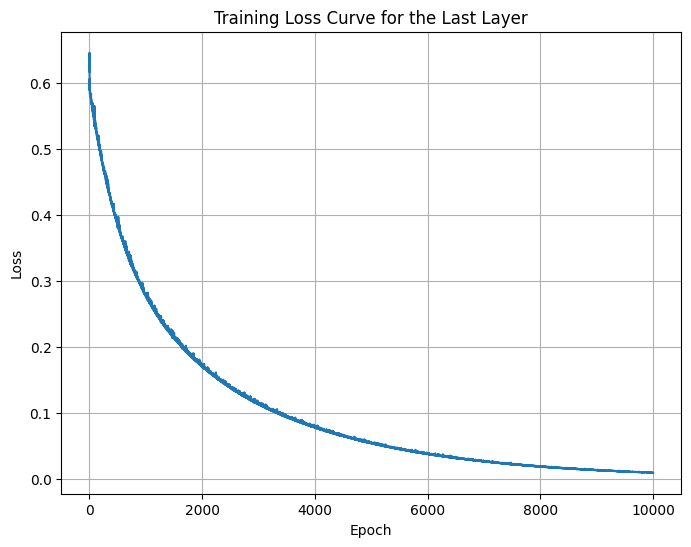

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

torch.manual_seed(19)

device = "cuda"

precomputed_train_dataset = precompute_features(base_model, north_dataset, device)
print("taille dataset north : ", len(north_dataset),"Taille dataset precomputed : ",len(precomputed_train_dataset))

#Dataloader with new dataset
train_loader = DataLoader(precomputed_train_dataset, batch_size=16, shuffle=True)

#Get dim of last layer
feature_dim = 512

# define just the linear layer to train
last_layer = nn.Linear(feature_dim, 2).to(device)

# loss function and optimizer.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(last_layer.parameters(), lr=1e-3)

# training loop
num_epochs = 10000
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    last_layer.train()
    for features, targets in train_loader:
        features = features.view(features.size(0), -1).to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = last_layer(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    if epoch % 1000 == 0:
      print(f"Epoch {epoch}/{num_epochs} - Loss: {epoch_loss:.4f}")

#Plot the training loss curve.
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for the Last Layer")
plt.grid(True)
plt.show()


In [9]:
#Add the trained last_layer to the model
base_model.fc.load_state_dict(last_layer.state_dict())
#Dataloader to perform inference
north_dataloader = DataLoader(north_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)



def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    return accuracy

base_model.fc.load_state_dict(last_layer.state_dict())

# Compute accuracy
north_accuracy = evaluate_accuracy(base_model, north_dataloader, device)
test_accuracy = evaluate_accuracy(base_model, test_dataloader, device)

print(f"North Dataset Accuracy: {north_accuracy:.2f}%")
print(f"Test Dataset Accuracy: {test_accuracy:.2f}%")

North Dataset Accuracy: 100.00%
Test Dataset Accuracy: 61.90%


Intermediate question : Provide the training process in the notebook with training curve. Comment on the accuracy.

<div class="alert alert-info">  **Intermediate question answer:** The accuracy is 100% on the training dataset and 64.29% on the test_dataset. Thus there is overfitting, + répondre avec le prof qui disait dernier cours qu'un réseau initialisé random pouvait avoir 100%</div>

## Question 3 :
> Now start from a pretained model on Imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `utils.py` containing only the last layer class `LastLayer` inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `last_layer_finetune.pth` file containing __only the last layer weights__ ( we will check the size)

 We will test your model on final accuracy on a test set.


## Preprocessing function

<div class="alert alert-info">We used this preprocessing function :  </div>

In [107]:
import torch
from torchvision import datasets, transforms

def preprocessing(path, data_augmentation=False):
  
    if data_augmentation:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225]),
        ])
        
    else:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),            
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

In [147]:
north_dataset = preprocessing(dir_path + "north_dataset_sample", data_augmentation=True)
test_dataset =  preprocessing(dir_path + "north_dataset_test", data_augmentation=False)

In [109]:
#from utils import LastLayer####AGAIN UNCOMMENT LATER AN CHECK
class LastLayer(nn.Module):
    def __init__(self):
        super(LastLayer, self).__init__()
        self.fc = nn.Linear(512, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

Epoch 0/1000 - Loss: 0.6602
Epoch 100/1000 - Loss: 0.4710
Epoch 200/1000 - Loss: 0.3500
Epoch 300/1000 - Loss: 0.2710
Epoch 400/1000 - Loss: 0.2167
Epoch 500/1000 - Loss: 0.1773
Epoch 600/1000 - Loss: 0.1474
Epoch 700/1000 - Loss: 0.1240
Epoch 800/1000 - Loss: 0.1051
Epoch 900/1000 - Loss: 0.0898


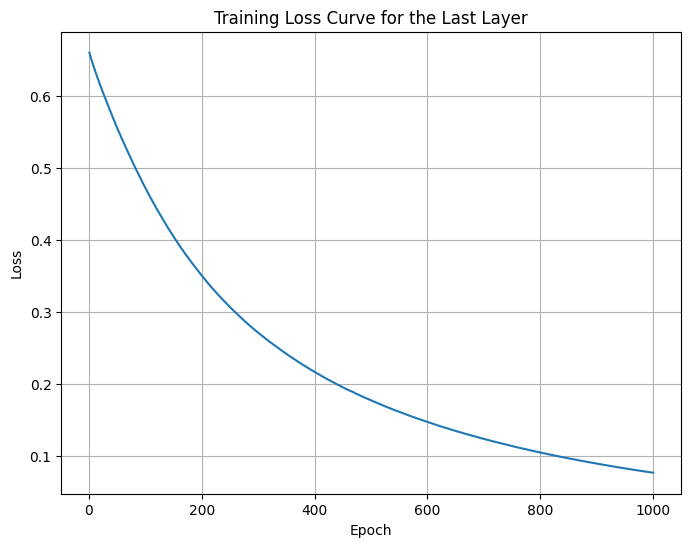

In [117]:
torch.manual_seed(19)

device = "cuda"
resnet = models.resnet18(weights="DEFAULT") #model pretrained
precomputed_train_dataset = precompute_features(resnet, north_dataset, device)

#Dataloader with new dataset
train_loader = DataLoader(precomputed_train_dataset, batch_size=16, shuffle=True)

# define just the linear layer to train
last_layer = LastLayer().to(device)

# loss function and optimizer.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(last_layer.parameters(), lr=3*1e-5)
# training loop
num_epochs = 1000
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    last_layer.train()
    for features, targets in train_loader:
        features = features.view(features.size(0), -1).to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = last_layer(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    if epoch % 100 == 0:
      print(f"Epoch {epoch}/{num_epochs} - Loss: {epoch_loss:.4f}")

#Plot the training loss curve.
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve for the Last Layer")
plt.grid(True)
plt.show()

# Save last layer
torch.save(last_layer.state_dict(), "last_layer_finetune.pth")



In [142]:
#Loading
last_layer = LastLayer()
last_layer.load_state_dict(torch.load("/kaggle/working/last_layer_finetune.pth",weights_only=True))
resnet = models.resnet18(weights="DEFAULT")
resnet.fc = last_layer
resnet.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [152]:
# Create dataloaders
north_dataloader = DataLoader(north_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Compute accuracy
north_accuracy = evaluate_accuracy(resnet, north_dataloader, device)
test_accuracy = evaluate_accuracy(resnet, test_dataloader, device)

print(f"North Dataset Accuracy: {north_accuracy:.2f}%")
print(f"Test Dataset Accuracy: {test_accuracy:.2f}%")

North Dataset Accuracy: 90.48%
Test Dataset Accuracy: 88.10%


## Question 4 :
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  (We are perfectly fine if you use an external library **for this question only**, and of course use it in the next questions). (Warning : without data augmentation it may not improve the accuracy.)

Intermediate question : Describe LoRA. There are different ways of implementing LoRa for convolutions. You can choose your preferred one. Explain the version of LoRa you used, provide a drawing of the process in the `drawing_lora.png` file. (Hint: you can obtain a small rank convolution by combining a convolution and a 1x1 convolution. One of the two goes from a higher number of channels to a lower number of channels and the other one restores the number of channels.)

<div class="alert alert-info"> LoRA is a method to fine-tune large pretrained models by freezing the original weights and adding trainable low-rank matrices that approximate weight updates. For convolutional layers, one common implementation uses a pair of 1×1 convolutions, one to reduce the channel dimension and one to restore it. Another approach applies a direct low-rank update. In our implementation using lora-pytorch, we use the default method that injects these low-rank updates into the network's layers. </div>

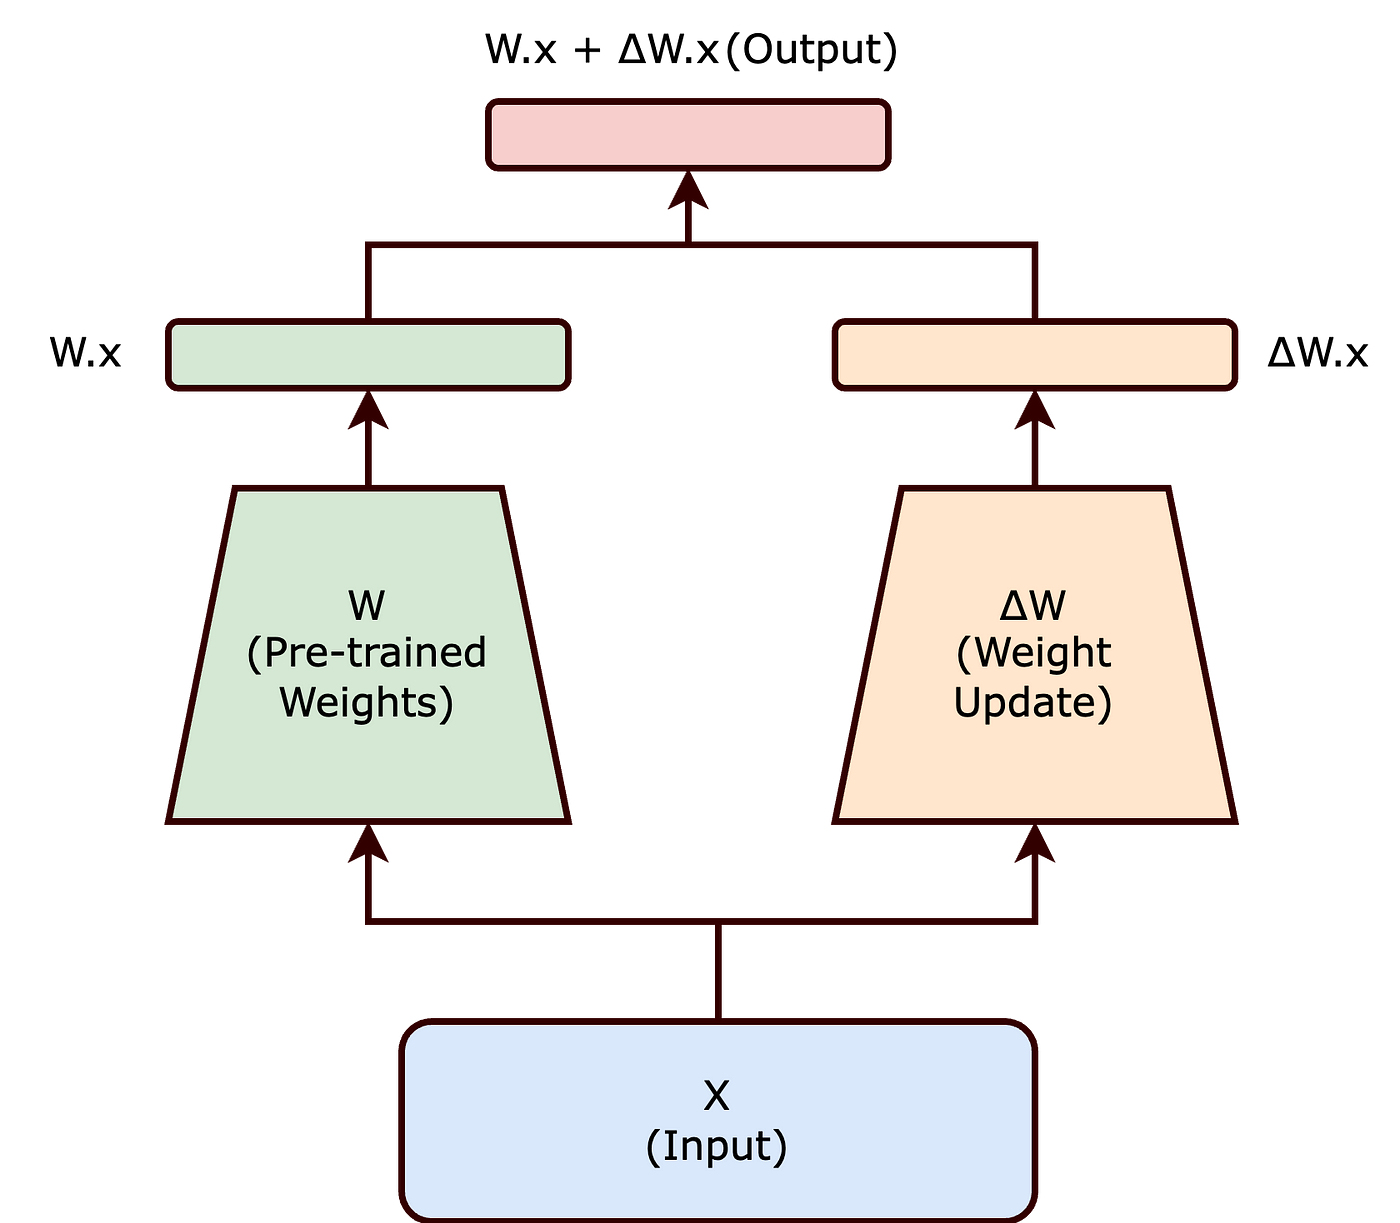
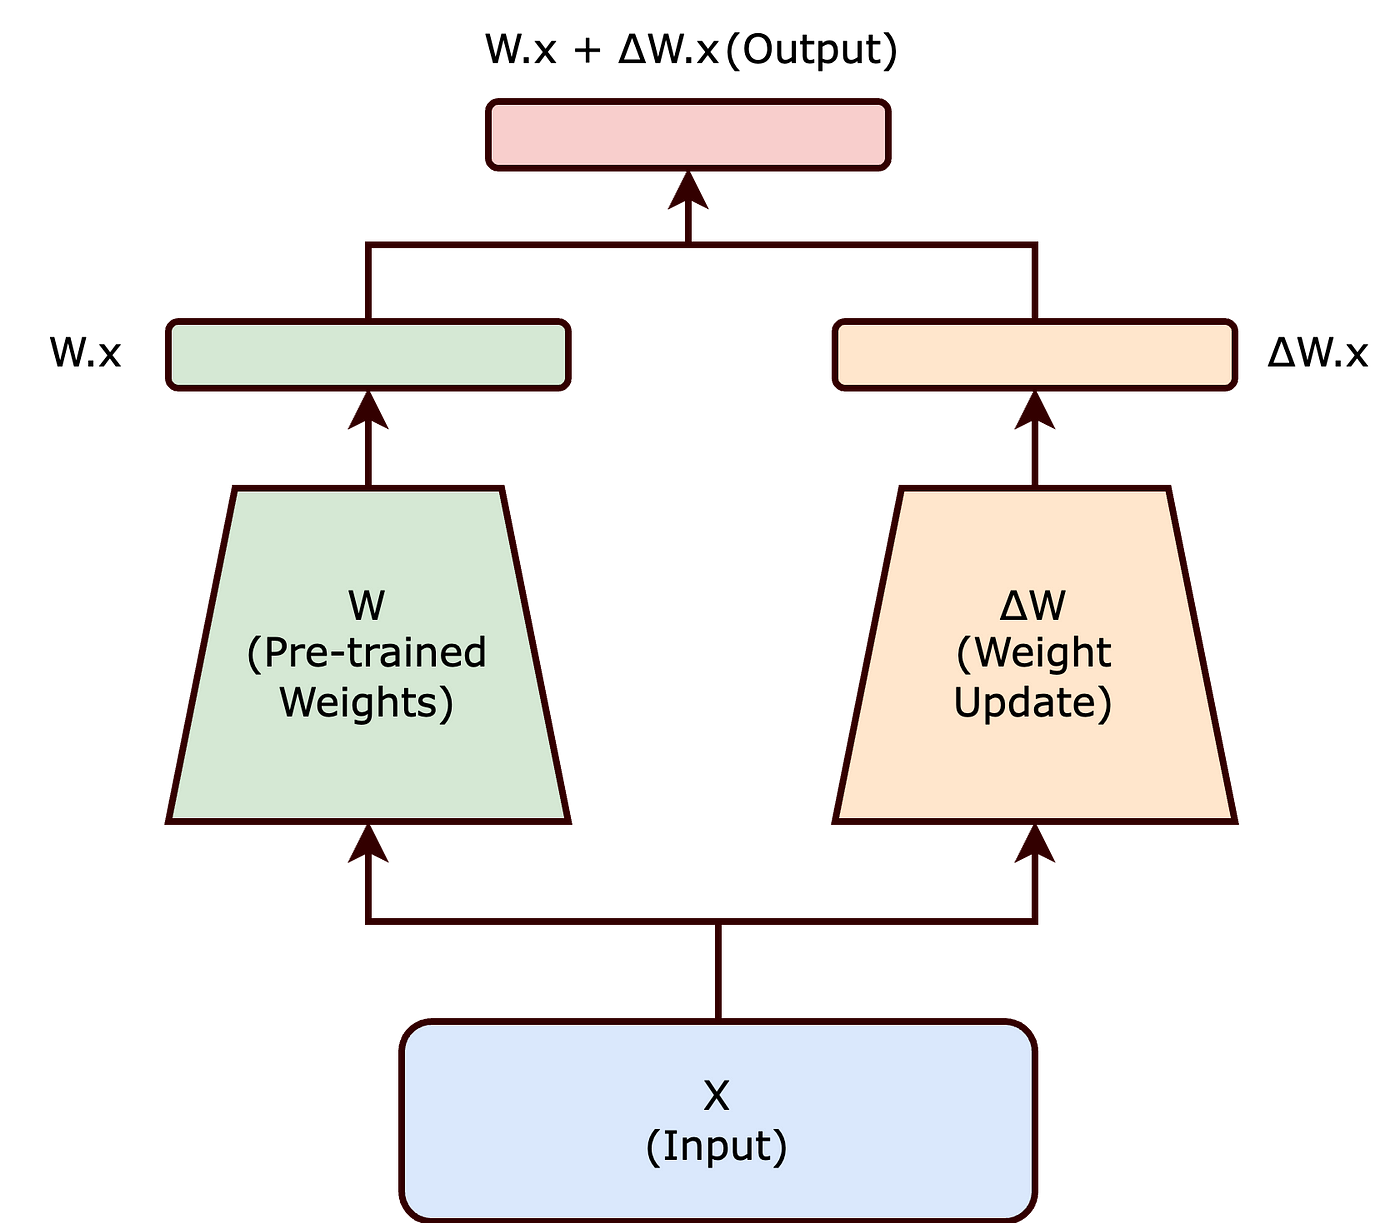
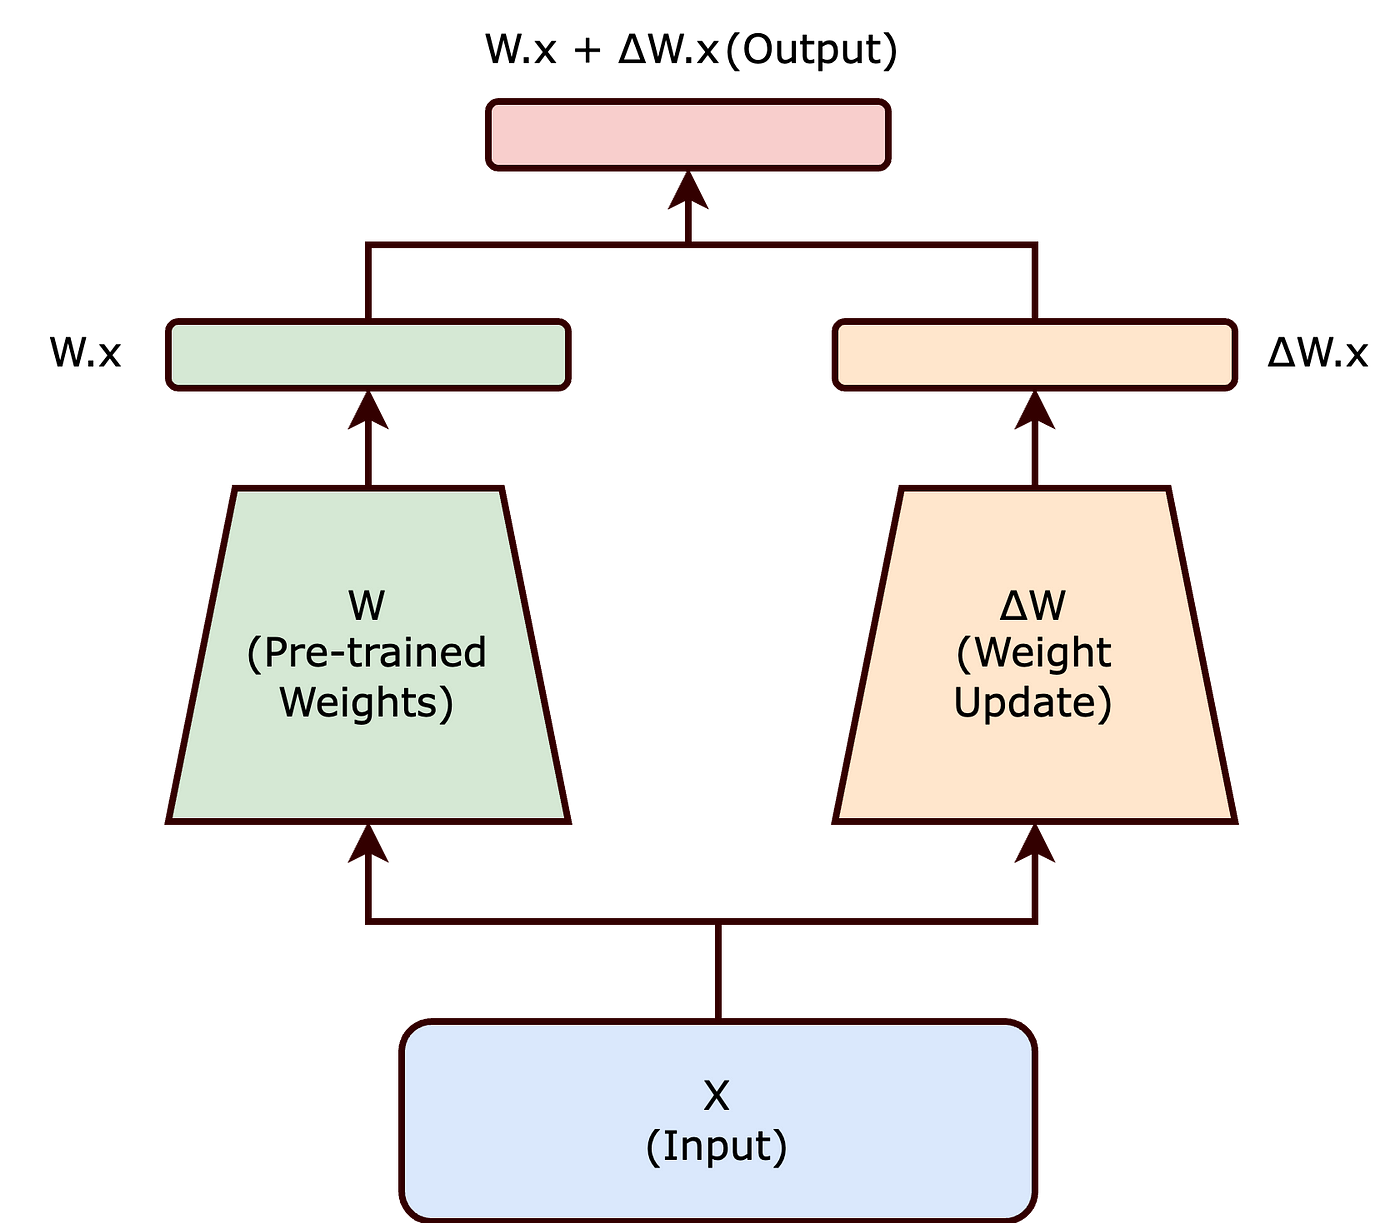

In [16]:
!pip install lora-pytorch

In [48]:
north_dataset = preprocessing(dir_path + "north_dataset_sample", data_augmentation=False)
test_dataset =  preprocessing(dir_path + "north_dataset_test", data_augmentation=False)

Epoch 0/2000 - Loss: 8.9519
Epoch 100/2000 - Loss: 7.2107
Epoch 200/2000 - Loss: 1.7515
Epoch 300/2000 - Loss: 0.3089
Epoch 400/2000 - Loss: 0.1971
Epoch 500/2000 - Loss: 0.0175
Epoch 600/2000 - Loss: 0.1791
Epoch 700/2000 - Loss: 0.4788
Epoch 800/2000 - Loss: 0.0149
Epoch 900/2000 - Loss: 0.0017
Epoch 1000/2000 - Loss: 0.0026
Epoch 1100/2000 - Loss: 0.0008
Epoch 1200/2000 - Loss: 0.0049
Epoch 1300/2000 - Loss: 0.0014
Epoch 1400/2000 - Loss: 0.0007
Epoch 1500/2000 - Loss: 0.0005
Epoch 1600/2000 - Loss: 0.0003
Epoch 1700/2000 - Loss: 0.0002
Epoch 1800/2000 - Loss: 0.0080
Epoch 1900/2000 - Loss: 0.0002


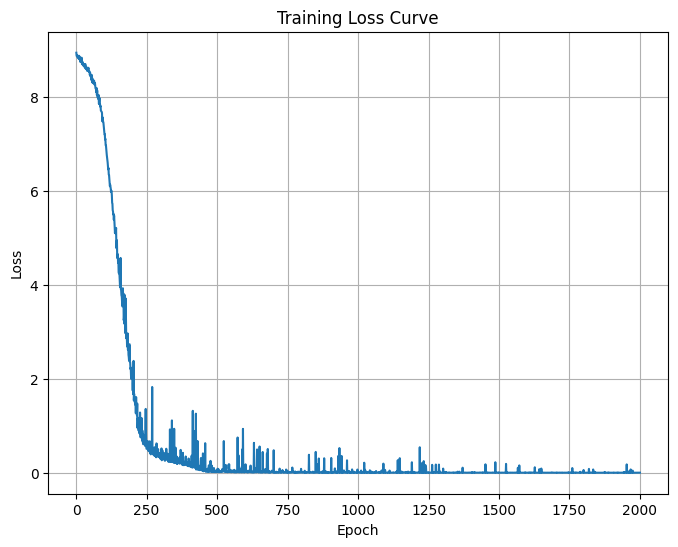

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
from lora_pytorch import LoRA

torch.manual_seed(19)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights="DEFAULT")

# Wrap your model with LoRA
lora_model = LoRA.from_module(resnet, rank=5).to(device)

train_loader = DataLoader(north_dataset, batch_size=16, shuffle=True)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lora_model.parameters(), lr=3*1e-5)

lora_model.train()

# Training loop
num_epochs = 2000
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for features, targets in train_loader:
        # Move data to the appropriate device
        features = features.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = lora_model(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{num_epochs} - Loss: {epoch_loss:.4f}")

# Plot the training loss curve.
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Merge LoRA weights into the original model.
new_model = lora_model.merge_lora(inplace=False)  # default: inplace=False

In [50]:
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Compute accuracy
north_accuracy = evaluate_accuracy(new_model, north_dataloader, device)
test_accuracy = evaluate_accuracy(new_model, test_dataloader, device)

print(f"North Dataset Accuracy: {north_accuracy:.2f}%")
print(f"Test Dataset Accuracy: {test_accuracy:.2f}%")

North Dataset Accuracy: 88.10%
Test Dataset Accuracy: 85.71%


## Question 5 :
In order to better train our LORA weights, let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them in your training pipeline.

 Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing `cutmix.png`.


  Provide one file : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a `daug_resnet.pth` file containing the weight of the ResNet18 after DAUG  (  !  It  has to be of the class ResNet so you have to merge LoRA weights with the ResNet18 weights)

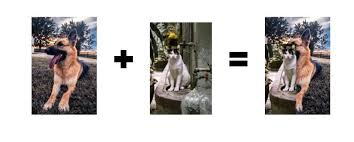

<div class="alert alert-info">   Preprocessing Function (reminder) </div>

In [51]:
import torch
from torchvision import datasets, transforms

def preprocessing(path, data_augmentation=False):
  
    if data_augmentation:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225]),
        ])
        
    else:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),            
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
    
    dataset = datasets.ImageFolder(root=path, transform=transform)
    return dataset

In [52]:
north_dataset = preprocessing(dir_path + "north_dataset_sample", data_augmentation=True)
test_dataset =  preprocessing(dir_path + "north_dataset_test", data_augmentation=False)

Epoch 0/1000 - Loss: 9.0705
Epoch 100/1000 - Loss: 0.4160
Epoch 200/1000 - Loss: 0.0526
Epoch 300/1000 - Loss: 0.0931
Epoch 400/1000 - Loss: 0.0469
Epoch 500/1000 - Loss: 0.0399
Epoch 600/1000 - Loss: 0.0014
Epoch 700/1000 - Loss: 0.0007
Epoch 800/1000 - Loss: 0.0003
Epoch 900/1000 - Loss: 0.0001


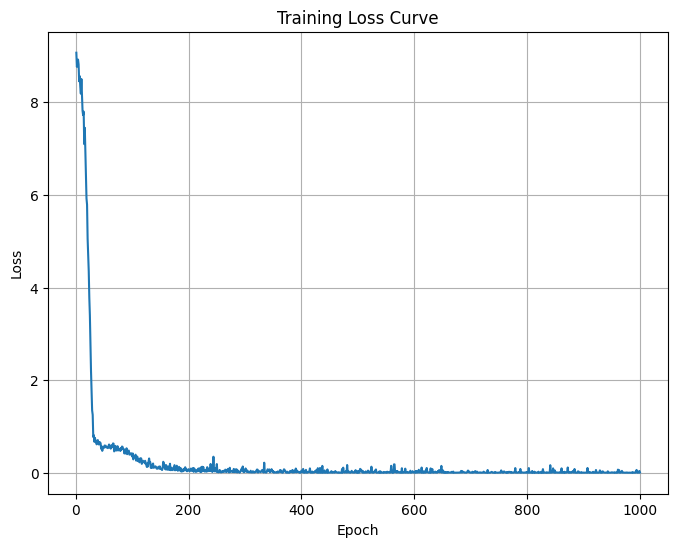

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
from lora_pytorch import LoRA

torch.manual_seed(19)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights="DEFAULT")

# Wrap your model with LoRA
lora_model = LoRA.from_module(resnet, rank=5).to(device)

train_loader = DataLoader(north_dataset, batch_size=16, shuffle=True)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lora_model.parameters(), lr=3*1e-4)

lora_model.train()

# Training loop
num_epochs = 1000
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0
    for features, targets in train_loader:
        # Move data to the appropriate device
        features = features.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = lora_model(features)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}/{num_epochs} - Loss: {epoch_loss:.4f}")

# Plot the training loss curve.
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Merge LoRA weights into the original model.
new_model = lora_model.merge_lora(inplace=False)  # default: inplace=False

In [61]:
torch.save(new_model.state_dict(), "daug_resnet.pth")

In [153]:
daug_resnet = models.resnet18(weights=None)
state_dict = torch.load("/kaggle/working/daug_resnet.pth",weights_only=True)
daug_resnet.load_state_dict(state_dict)
daug_resnet.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [157]:
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Compute accuracy
north_accuracy = evaluate_accuracy(daug_resnet, north_dataloader, device)
test_accuracy = evaluate_accuracy(daug_resnet, test_dataloader, device)

print(f"North Dataset Accuracy: {north_accuracy:.2f}%")
print(f"Test Dataset Accuracy: {test_accuracy:.2f}%")

North Dataset Accuracy: 100.00%
Test Dataset Accuracy: 90.48%


## Question 6 : (BONUS)
> Do the best you can : improve performance on test set while keeping ResNet 18 architecture, or decrease the size of the model

Provide a file  `final_model.pth` containing the weights of the final model and provide the class `FinalModel()` in the `utils.py` file.